In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("temiz_veri/model_verisi.csv", index_col='datetime', parse_dates=True)

print("Veri boyutu:", df.shape)
df.head(3)

Veri boyutu: (34000, 21)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,temperature_2m,relative_humidity_2m,precipitation,...,gun,ay,yil,yilin_gunu,hafta_sonu,mevsim,tuketim_lag_1,tuketim_lag_24,tuketim_lag_168,tuketim_rolling_24
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,4.0,84,0.0,...,5,12,2006,357,1,0,4.349100,1.496800,4.222889,2.934890
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,3.7,86,0.0,...,5,12,2006,357,1,0,5.452533,2.686967,3.632200,3.099713
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,3.6,87,0.0,...,5,12,2006,357,1,0,3.879400,3.938167,3.400233,3.149397


In [2]:
# Tahmin edeceğimiz değer (hedef)
hedef = 'Global_active_power'

# Modele verilecek özellikler
ozellikler = [
    'saat', 'gun', 'ay', 'yil', 'yilin_gunu',
    'hafta_sonu', 'mevsim',
    'temperature_2m', 'relative_humidity_2m', 'precipitation',
    'tuketim_lag_1', 'tuketim_lag_24', 'tuketim_lag_168',
    'tuketim_rolling_24'
]

X = df[ozellikler]
y = df[hedef]

print("Özellik matrisi boyutu:", X.shape)
print("Hedef değişken boyutu:", y.shape)

Özellik matrisi boyutu: (34000, 14)
Hedef değişken boyutu: (34000,)


In [3]:
# Son 1 yılı test, gerisini eğitim olarak ayır
# (zaman serisi olduğu için rastgele bölmüyoruz!)
bolme_tarihi = '2010-01-01'

X_egitim = X[X.index < bolme_tarihi]
X_test = X[X.index >= bolme_tarihi]
y_egitim = y[y.index < bolme_tarihi]
y_test = y[y.index >= bolme_tarihi]

print(f"Eğitim seti: {len(X_egitim):,} satır ({X_egitim.index.min().date()} → {X_egitim.index.max().date()})")
print(f"Test seti:   {len(X_test):,} satır ({X_test.index.min().date()} → {X_test.index.max().date()})")

Eğitim seti: 26,373 satır (2006-12-23 → 2009-12-31)
Test seti:   7,627 satır (2010-01-01 → 2010-11-26)


In [4]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("Model eğitiliyor...")
model.fit(X_egitim, y_egitim)
print("Eğitim tamamlandı ✓")

Model eğitiliyor...
Eğitim tamamlandı ✓


In [5]:
y_tahmin = model.predict(X_test)

mae = mean_absolute_error(y_test, y_tahmin)
rmse = np.sqrt(mean_squared_error(y_test, y_tahmin))
r2 = r2_score(y_test, y_tahmin)

print("=" * 35)
print("MODEL PERFORMANSI")
print("=" * 35)
print(f"MAE  (Ortalama Mutlak Hata): {mae:.4f} kW")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse:.4f} kW")
print(f"R²   (Açıklama Gücü): {r2:.4f}")
print("=" * 35)

MODEL PERFORMANSI
MAE  (Ortalama Mutlak Hata): 0.3464 kW
RMSE (Kök Ortalama Kare Hata): 0.4993 kW
R²   (Açıklama Gücü): 0.5924


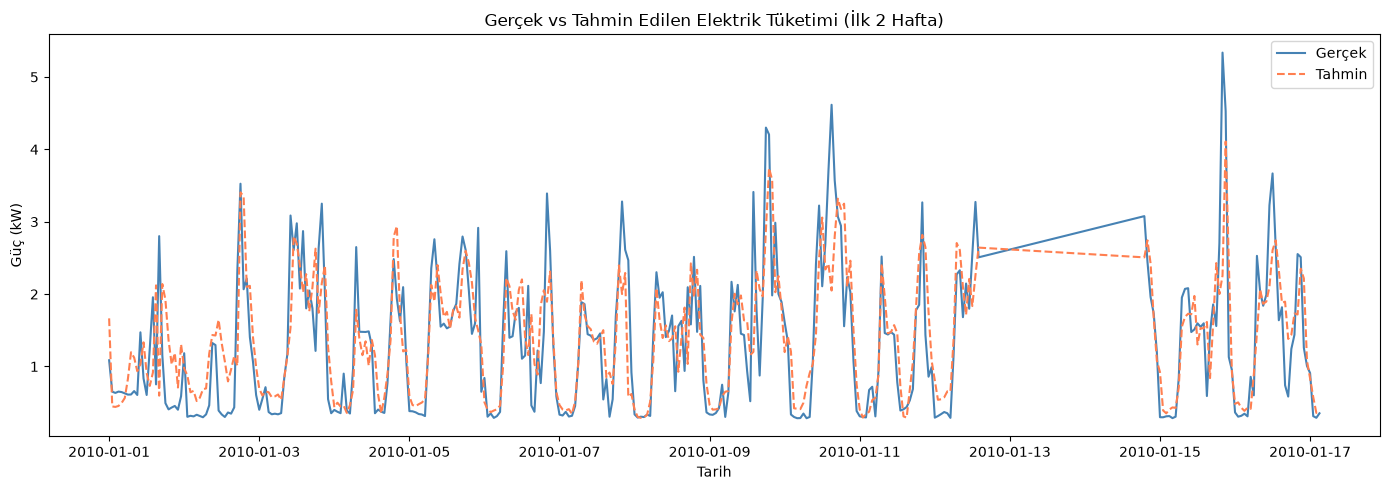

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

# Sadece ilk 2 haftayı göster (daha okunabilir)
goster = 24 * 14

ax.plot(y_test.index[:goster], y_test.values[:goster], 
        label='Gerçek', color='steelblue', linewidth=1.5)
ax.plot(y_test.index[:goster], y_tahmin[:goster], 
        label='Tahmin', color='coral', linewidth=1.5, linestyle='--')

ax.set_title('Gerçek vs Tahmin Edilen Elektrik Tüketimi (İlk 2 Hafta)')
ax.set_ylabel('Güç (kW)')
ax.set_xlabel('Tarih')
ax.legend()
plt.tight_layout()
plt.show()

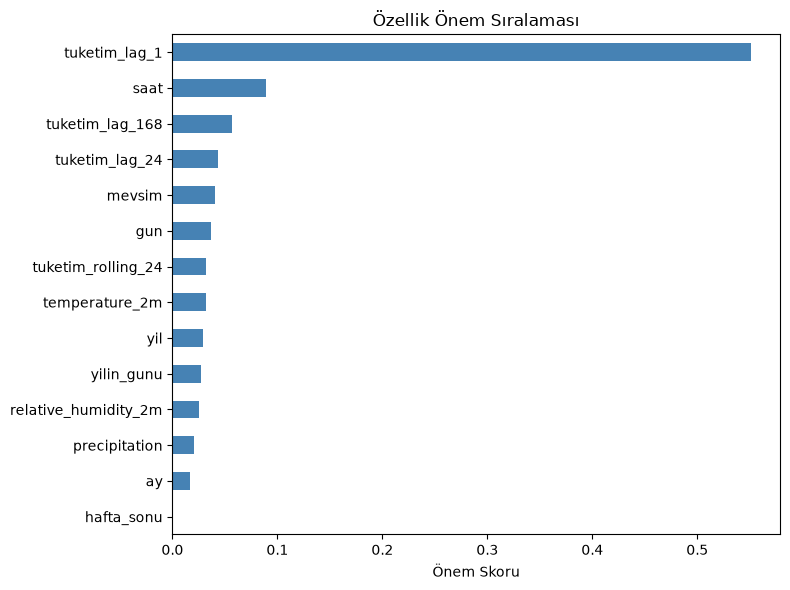

In [7]:
onem = pd.Series(model.feature_importances_, index=ozellikler)
onem = onem.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
onem.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Özellik Önem Sıralaması')
ax.set_xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

In [8]:
import os
import pickle

os.makedirs("model", exist_ok=True)

with open("model/xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model kaydedildi: model/xgboost_model.pkl ✓")

Model kaydedildi: model/xgboost_model.pkl ✓
